In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow.keras as tf

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
train_datagen = ImageDataGenerator(

rescale=1./255,

rotation_range=20,

zoom_range=0.2,

shear_range=0.2,

horizontal_flip=True

)

test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_generator = train_datagen.flow_from_directory('datasetss/Fruits Classification/train', target_size=(128,128), class_mode='sparse')

Found 9700 images belonging to 5 classes.


In [5]:
test_generator = test_datagen.flow_from_directory('datasetss/Fruits Classification/test', target_size=(128,128), class_mode='sparse')

Found 100 images belonging to 5 classes.


In [6]:
train_generator

In [7]:
data,lable = next(train_generator)       
data.shape

(32, 128, 128, 3)

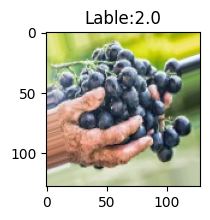

In [8]:
# just for cheak
plt.figure(figsize=(2,2))
plt.imshow(data[18])   # from 32 image take image
plt.title(f'Lable:{lable[18]}')    # take lable of image & show it as title as image
plt.show()

In [9]:
cnn = tf.models.Sequential()

cnn.add(tf.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[128,128,3]))
cnn.add(tf.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
cnn.add(tf.layers.MaxPool2D(pool_size=2, strides=2))
cnn.add(tf.layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
cnn.add(tf.layers.Flatten())

cnn.add(tf.layers.Dense(units=128, activation='relu'))   

cnn.add(tf.layers.Dropout(0.5))

cnn.add(tf.layers.Dense(units=5, activation='softmax'))     # output layer       

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,939,077 (49.36 MB)

 Trainable params: 12,939,077 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.fit(train_generator, epochs=10, validation_data=test_generator)

Epoch 1/10
153/304 ━━━━━━━━━━━━━━━━━━━━ 1:29 591ms/step - accuracy: 0.3080 - loss: 1.6294

In [16]:
cnn.evaluate(train_generator)

304/304 ━━━━━━━━━━━━━━━━━━━━ 44s 146ms/step - accuracy: 0.7386 - loss: 0.6979


[0.6978890895843506, 0.7385566830635071]

In [17]:
cnn.evaluate(test_generator)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6800 - loss: 1.0542


[1.0542497634887695, 0.6800000071525574]

In [18]:
cnn.save("fruit_model.h5")

In [21]:
import numpy as np
from keras.utils import load_img,img_to_array

img = load_img(
'datasetss/Fruits Classification/valid/All_mix/Strawberry (443).jpeg',
target_size=(128,128)
)

img = img_to_array(img)

img = img/255

img = np.expand_dims(img,axis=0)

result = cnn.predict(img)

classes = list(train_generator.class_indices.keys())

prediction = classes[np.argmax(result)]

print("Prediction:",prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction: Strawberry
